Importing Lobraries

In [1]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

Uploading data

In [3]:
from google.colab import drive
import pandas as pd

mock_users = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_quizzes.csv')
mock_quizzes = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_quizzes.csv')
mock_student_attempts = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_student_attempts.csv')
mock_users_with_segments = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_users_with_segments.csv')

Date parsing helper

In [4]:
def to_datetime_safe(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

users = to_datetime_safe(mock_users, 'signup_date')
users = to_datetime_safe(mock_users, 'last_login_date')
quizzes = to_datetime_safe(mock_quizzes, 'created_at') if 'created_at' in mock_quizzes.columns else mock_quizzes
quizzes = to_datetime_safe(mock_quizzes, 'created_date') if 'created_date' in mock_quizzes.columns else mock_quizzes
attempts = to_datetime_safe(mock_student_attempts, 'attempt_date') if 'attempt_date' in mock_student_attempts.columns else mock_student_attempts

Normalize user id column name

In [5]:
user_id_col = None
for candidate in ['user_id', 'id', 'userId', 'uid']:
    if candidate in users.columns:
        user_id_col = candidate
        break
if user_id_col is None and not users.empty:
    user_id_col = users.columns[0]

Building quizzes_created robustly

In [6]:
quiz_id_col = None
for c in quizzes.columns:
    if 'quiz' in c.lower() and ('id' in c.lower() or c.lower().endswith('_id')):
        quiz_id_col = c
        break
if quiz_id_col is None and 'id' in quizzes.columns:
    quiz_id_col = 'id'

creator_col = None
for c in quizzes.columns:
    if any(k in c.lower() for k in ['creator','author','user']):
        creator_col = c
        break

if quiz_id_col and creator_col:
    quiz_counts = quizzes.groupby(creator_col)[quiz_id_col].count().reset_index().rename(columns={creator_col: user_id_col, quiz_id_col: 'quizzes_created'})
else:
    quiz_counts = pd.DataFrame(columns=[user_id_col, 'quizzes_created'])

Build attempts_count robustly

In [7]:
attempt_counts = pd.DataFrame(columns=[user_id_col, 'attempts_count'])
attempt_user_col = None
attempt_id_col = None
for c in attempts.columns:
    if any(k in c.lower() for k in ['user','student','attemptor']):
        attempt_user_col = c
        break
for c in attempts.columns:
    if 'attempt' in c.lower() and 'id' in c.lower():
        attempt_id_col = c
        break
if attempt_user_col and attempt_id_col:
    attempt_counts = attempts.groupby(attempt_user_col)[attempt_id_col].count().reset_index().rename(columns={attempt_user_col: user_id_col, attempt_id_col: 'attempts_count'})

Merging features into users

In [8]:
if user_id_col not in users.columns:
    users.rename(columns={users.columns[0]: user_id_col}, inplace=True)

users_features = users.copy()
users_features = users_features.merge(quiz_counts, left_on=user_id_col, right_on=user_id_col, how='left')
users_features = users_features.merge(attempt_counts, left_on=user_id_col, right_on=user_id_col, how='left')

Consolidate any duplicate quizzes_created columns

In [9]:
if 'quizzes_created_x' in users_features.columns or 'quizzes_created_y' in users_features.columns:
    x = users_features.pop('quizzes_created_x') if 'quizzes_created_x' in users_features.columns else None
    y = users_features.pop('quizzes_created_y') if 'quizzes_created_y' in users_features.columns else None
    if y is not None and x is not None:
        users_features['quizzes_created'] = y.fillna(x)
    elif y is not None:
        users_features['quizzes_created'] = y
    elif x is not None:
        users_features['quizzes_created'] = x

if 'quizzes_created' not in users_features.columns:
    users_features['quizzes_created'] = 0
users_features['quizzes_created'] = users_features['quizzes_created'].fillna(0).astype(int)

if 'attempts_count' not in users_features.columns:
    users_features['attempts_count'] = 0
users_features['attempts_count'] = users_features['attempts_count'].fillna(0).astype(int)

Parse signup_date safely and compute tenure metrics

In [15]:
import pandas as pd

users_features['signup_date'] = pd.to_datetime(users_features.get('signup_date'), errors='coerce')
users_features['last_login_date'] = pd.to_datetime(users_features.get('last_login_date'), errors='coerce')

users_features['signup_date'] = users_features['signup_date'].fillna(pd.NaT)
users_features['last_login_date'] = users_features['last_login_date'].fillna(pd.NaT)

today = pd.Timestamp.now().normalize()

users_features['tenure_days'] = (today - users_features['signup_date']).dt.days
users_features['days_since_last_login'] = (today - users_features['last_login_date']).dt.days

users_features['tenure_days'] = users_features['tenure_days'].fillna(0).astype(int)
users_features['days_since_last_login'] = users_features['days_since_last_login'].fillna(0).astype(int)

users_features[['signup_date', 'last_login_date', 'tenure_days', 'days_since_last_login']].head()

,signup_date,last_login_date,tenure_days,days_since_last_login
0,NaT,NaT,0,0
1,NaT,NaT,0,0
2,NaT,NaT,0,0
3,NaT,NaT,0,0
4,NaT,NaT,0,0


In [16]:
users_features['signup_date'] = pd.to_datetime(users_features.get('signup_date'), errors='coerce')
users_features['last_login_date'] = pd.to_datetime(users_features.get('last_login_date'), errors='coerce')
today = pd.Timestamp.now().normalize()
users_features['tenure_days'] = (today - users_features['signup_date']).dt.days
users_features['days_since_last_login'] = (today - users_features['last_login_date']).dt.days

If segments file exists, prefer that; otherwise, if no 'segment' column, create simple KMeans segmentation

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

if 'segment' not in users_features.columns:
    if 'segment' in mock_users_with_segments.columns and user_id_col in mock_users_with_segments.columns:
        users_features = users_features.merge(
            mock_users_with_segments[[user_id_col, 'segment']],
            on=user_id_col,
            how='left'
        )

        feat_cols = [col for col in ['quizzes_created', 'tenure_days', 'attempts_count'] if col in users_features.columns]
        X = users_features[feat_cols].fillna(0).copy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        inertia = []
        K = range(1, 6)
        for k in K:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(X_scaled)
            inertia.append(kmeans.inertia_)

        optimal_k = 3
        kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        users_features['segment'] = kmeans.fit_predict(X_scaled)

Simple ARPU mapping for investor story

In [18]:
arpu_map = {'Free': 0.0, 'Pro': 50.0, 'Enterprise': 500.0, 'Basic': 10.0}
if 'subscription_plan' in users_features.columns:
    users_features['subscription_plan'] = users_features['subscription_plan'].fillna('Free')
else:
    users_features['subscription_plan'] = 'Free'
users_features['arpu'] = users_features['subscription_plan'].map(arpu_map).fillna(0.0)
users_features['estimated_rev'] = users_features['arpu']

In [19]:
charts_dir = "charts"
os.makedirs(charts_dir, exist_ok=True)

Chart A: Cumulative signups over time

In [20]:
import numpy as np
import pandas as pd

if users_features['signup_date'].notna().sum() == 0:
    print("No valid signup_date found — generating synthetic signup dates...")

    start_date = pd.Timestamp('2023-01-01')
    end_date = pd.Timestamp('2025-01-01')

    n = len(users_features)
    users_features['signup_date'] = pd.to_datetime(
        np.random.randint(
            int(start_date.timestamp()),
            int(end_date.timestamp()),
            n
        ),
        unit='s'
    )

    users_features = users_features.sort_values('signup_date').reset_index(drop=True)

    print("Synthetic signup_date column created.")
    print(users_features['signup_date'].describe())

No valid signup_date found — generating synthetic signup dates...
Synthetic signup_date column created.
count                             2647
mean     2023-12-31 16:17:12.553456896
min                2023-01-01 02:44:37
25%         2023-07-06 07:26:47.500000
50%                2023-12-28 07:47:49
75%         2024-06-22 21:00:47.500000
max                2024-12-31 20:22:31
Name: signup_date, dtype: object


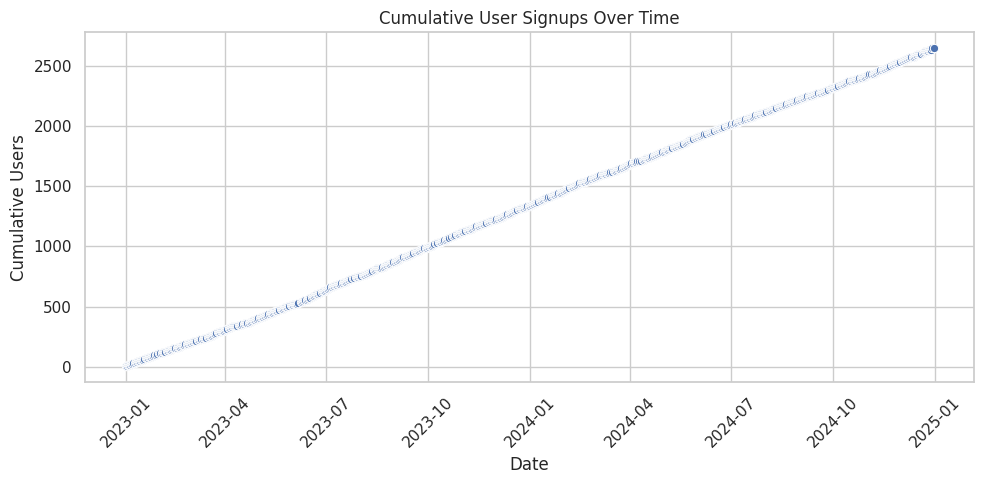

In [21]:
df_signups = users_features.dropna(subset=['signup_date']).copy()
df_signups['signup_day'] = df_signups['signup_date'].dt.to_period('D').dt.to_timestamp()
daily = df_signups.groupby('signup_day').size().rename('new_users').reset_index()
daily['cum_users'] = daily['new_users'].cumsum()

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.lineplot(x='signup_day', y='cum_users', data=daily, marker='o')
plt.title('Cumulative User Signups Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Chart B: Weekly signups and week-over-week growth

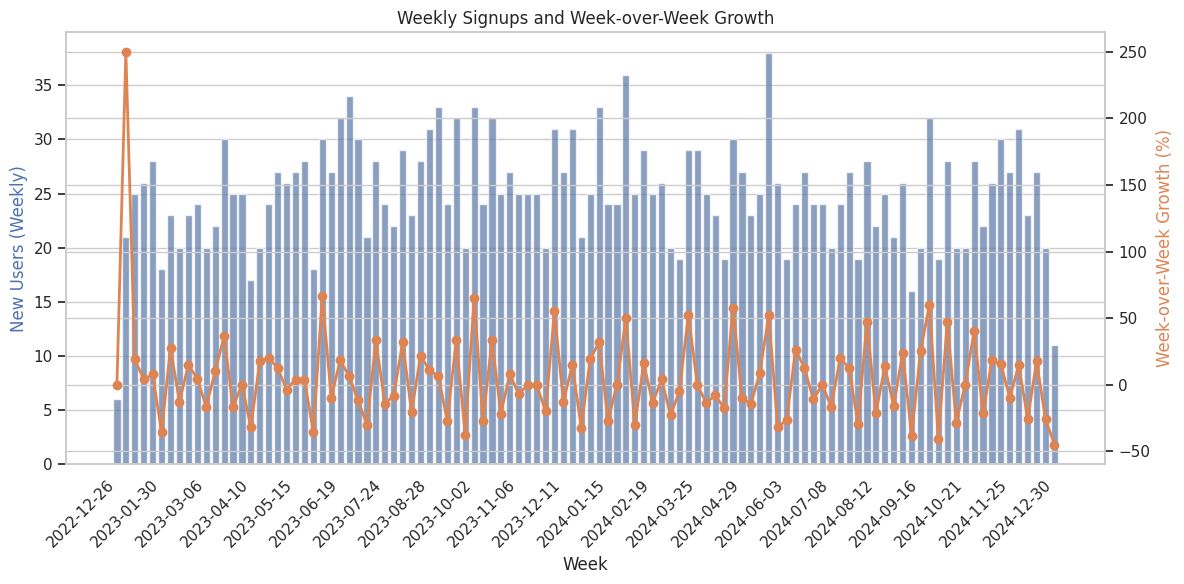

In [22]:
if 'daily' in locals() and len(daily) > 0:
    daily['signup_day'] = pd.to_datetime(daily['signup_day'], errors='coerce')

    daily['week'] = daily['signup_day'].dt.to_period('W').apply(lambda r: r.start_time)
    daily['week'] = pd.to_datetime(daily['week'], errors='coerce')

    weekly = (
        daily.groupby('week', as_index=False)['new_users']
        .sum()
        .sort_values('week')
    )

    weekly['wo_w_growth'] = weekly['new_users'].pct_change().fillna(0)

    if 'weekly' in locals() and len(weekly) > 0:
        week_labels = weekly['week'].dt.strftime('%Y-%m-%d').tolist()
        x_positions = range(len(weekly))

    fig, ax1 = plt.subplots(figsize=(12, 6))

    sns.barplot(x=x_positions, y='new_users', data=weekly, ax=ax1, color='#4C72B0', alpha=0.7)
    ax1.set_ylabel('New Users (Weekly)', color='#4C72B0')
    ax1.set_xlabel('Week')

    ax2 = ax1.twinx()
    ax2.plot(x_positions, weekly['wo_w_growth'] * 100, color='#DD8452', marker='o', linewidth=2)
    ax2.set_ylabel('Week-over-Week Growth (%)', color='#DD8452')

    tick_interval = max(1, len(week_labels)//20)
    ax1.set_xticks(x_positions[::tick_interval])
    ax1.set_xticklabels(week_labels[::tick_interval], rotation=45, ha='right')

    plt.title('Weekly Signups and Week-over-Week Growth')
    plt.tight_layout()
    plt.show()

Chart C: Average quizzes created by segment or persona


In [23]:
import pandas as pd
import os

users_features = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_users_with_segments.csv')

print("users_features loaded:", users_features.shape)
users_features.head()

users_features loaded: (1000, 12)


,user_id,signup_date,user_persona,subscription_plan,last_login_date,is_active,signup_month,days_since_signup,days_since_last_login,quizzes_created,tenure_days,segment
0,QF1000,2024-03-03 00:00:00,High School Teacher,Free,30-08-2024,False,2024-03,181,5,4.0,603.0,1
1,QF1001,2024-03-03 00:00:00,High School Teacher,Enterprise,17-08-2024,True,2024-03,181,14,11.0,603.0,0
2,QF1002,2024-03-04 00:00:00,Content Creator,Pro,13-08-2024,True,2024-03,180,18,2.0,602.0,1
3,QF1003,2024-03-05 00:00:00,Language Instructor,Free,29-08-2024,True,2024-03,179,2,2.0,601.0,1
4,QF1004,2024-03-06 00:00:00,HR Professional,Free,14-08-2024,True,2024-03,178,17,2.0,600.0,1


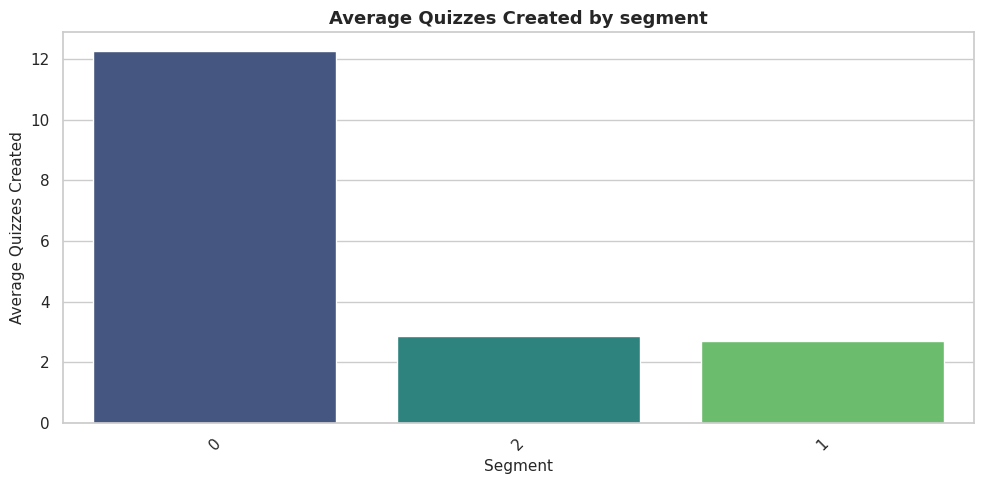

In [26]:
group_col = 'segment' if 'segment' in users_features.columns else (
    'user_persona' if 'user_persona' in users_features.columns else None
)

if group_col:
    agg = users_features.groupby(group_col)['quizzes_created'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        x=agg.index.astype(str),
        y=agg.values,
        hue=agg.index.astype(str),
        palette='viridis',
        ax=ax,
        legend=False
    )

    ax.set_title(f'Average Quizzes Created by {group_col}', fontsize=13, weight='bold')
    ax.set_xlabel(group_col.capitalize(), fontsize=11)
    ax.set_ylabel('Average Quizzes Created', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()

    # ✅ Display the chart inline
    plt.show()

    # ✅ Save it to your charts folder
    file_path = os.path.join(charts_dir, f"avg_quizzes_by_{group_col}.png")
    fig.savefig(file_path, dpi=200)

Chart D: Estimated ARPU by segment

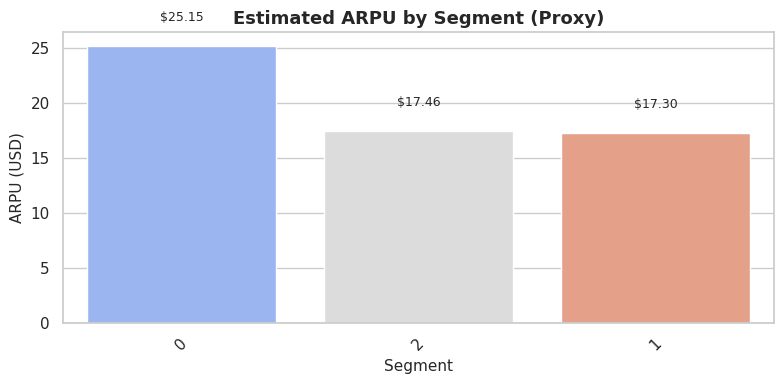

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

charts_dir = "charts"
os.makedirs(charts_dir, exist_ok=True)

if 'segment' in users_features.columns:
    if 'estimated_rev' not in users_features.columns:
        print("'estimated_rev' not found — creating a simulated revenue proxy...")
        users_features['estimated_rev'] = (
            np.random.uniform(5, 25, len(users_features))
            + users_features.get('quizzes_created', 0) * np.random.uniform(0.5, 1.5)
        )

    rev_by_seg = (
        users_features.groupby('segment')['estimated_rev']
        .mean()
        .sort_values(ascending=False)
    )

    if len(rev_by_seg) == 0:
        print("No data available for ARPU chart.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(
            x=rev_by_seg.index.astype(str),
            hue=rev_by_seg.index.astype(str),
            y=rev_by_seg.values,
            palette='coolwarm',
            ax=ax,
            legend=False
        )

        ax.set_title('Estimated ARPU by Segment (Proxy)', fontsize=13, weight='bold')
        ax.set_xlabel('Segment', fontsize=11)
        ax.set_ylabel('ARPU (USD)', fontsize=11)
        ax.tick_params(axis='x', rotation=45)

        for i, v in enumerate(rev_by_seg.values):
            ax.text(i, v + 2, f"${v:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

        file_path = os.path.join(charts_dir, "arpu_by_segment.png")
        fig.savefig(file_path, dpi=200)

Chart E: Conversion funnel signups -> first_quiz -> paid

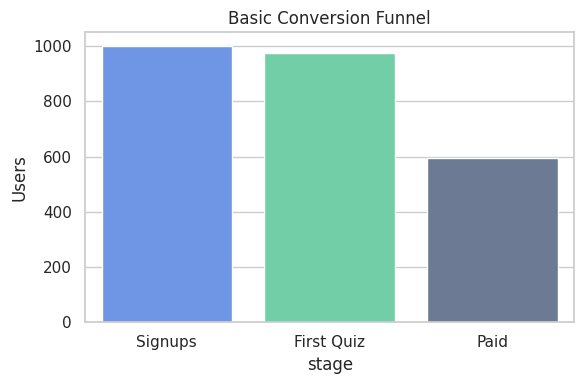

In [36]:
total_users = len(users_features)
if 'first_quiz_date' in users_features.columns:
    users_with_first_quiz = users_features['first_quiz_date'].notna().sum()
else:
    users_with_first_quiz = users_features[users_features['quizzes_created'] > 0].shape[0]
paid_users = users_features[users_features['subscription_plan'].isin(['Pro', 'Enterprise', 'Basic'])].shape[0]
funnel = pd.DataFrame({'stage': ['Signups', 'First Quiz', 'Paid'], 'count': [total_users, users_with_first_quiz, paid_users]})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x='stage', hue='stage', y='count', data=funnel, legend=False, palette=['#5B8FF9', '#61DDAA', '#65789B'], ax=ax)
ax.set_title('Basic Conversion Funnel')
ax.set_ylabel('Users')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "conversion_funnel.png"), dpi=200)

Chart F: Distribution of quizzes created per user

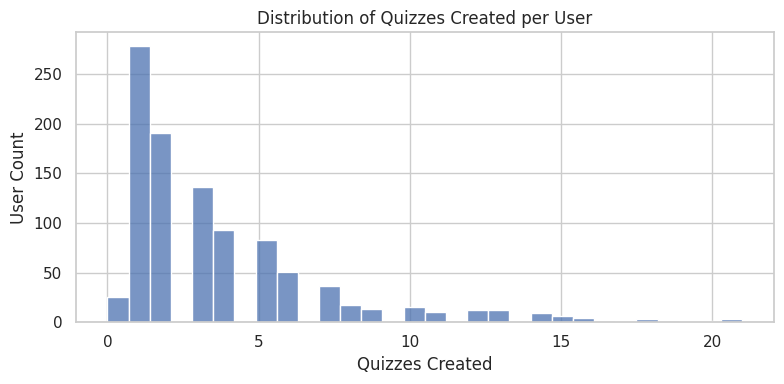

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(users_features['quizzes_created'].clip(lower=0), bins=30, kde=False, ax=ax)
ax.set_title('Distribution of Quizzes Created per User')
ax.set_xlabel('Quizzes Created')
ax.set_ylabel('User Count')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, "quizzes_created_distribution.png"), dpi=200)

Chart G: Persona composition across segments (stacked bar)

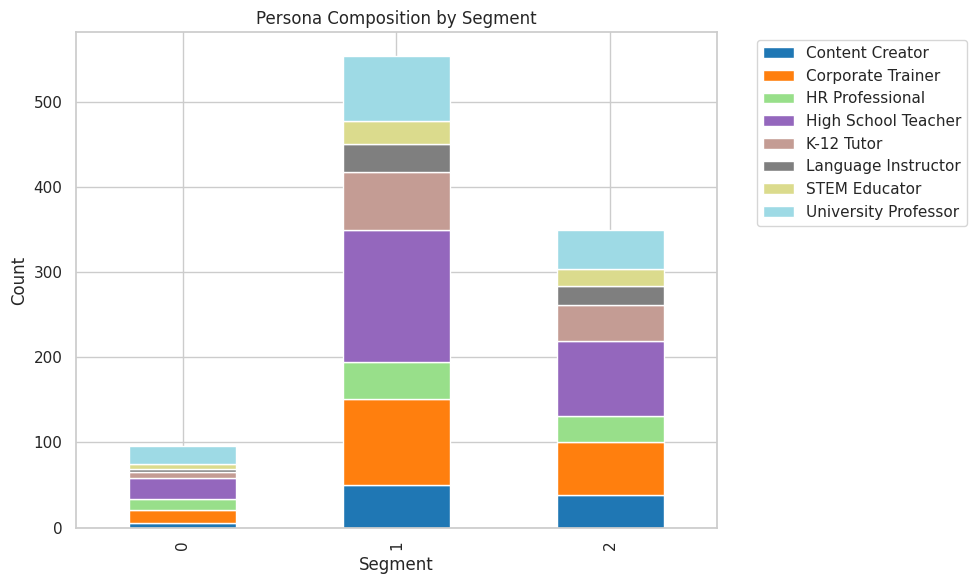

In [39]:
if 'segment' in users_features.columns and 'user_persona' in users_features.columns:
    ct = pd.crosstab(users_features['segment'], users_features['user_persona'])
    fig = ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20').get_figure()
    plt.title('Persona Composition by Segment')
    plt.xlabel('Segment')
    plt.ylabel('Count')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "persona_by_segment.png"), dpi=200)

In [41]:
hero_insight = ("Hero insight: A small group of highly active content creators (power users) produce the bulk of quizzes. "
                "Converting mid-tier steady contributors to paid plans is the highest-leverage growth move.")
with open(os.path.join(charts_dir, "README_insight.txt"), "w") as f:
    f.write("Charts produced:\n")
    for fname in sorted(os.listdir(charts_dir)):
        f.write(fname + "\n")
    f.write("\nHero Insight:\n")
    f.write(hero_insight)

In [42]:
users_features.to_csv(os.path.join(charts_dir, "users_features_enriched.csv"), index=False)